# Explore here

In [1]:
%pip install requests pandas matplotlib seaborn sqlalchemy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests

In [ ]:


url = 'https://api.worldbank.org/v2/country/chn;ago/indicator/SP.POP.TOTL?date=2010:2024&format=json'

response = requests.get(url)
response.text

'[{"page":1,"pages":1,"per_page":50,"total":30,"sourceid":"2","lastupdated":"2026-04-08"},[{"indicator":{"id":"SP.POP.TOTL","value":"Population, total"},"country":{"id":"AO","value":"Angola"},"countryiso3code":"AGO","date":"2024","value":37885849,"unit":"","obs_status":"","decimal":0},{"indicator":{"id":"SP.POP.TOTL","value":"Population, total"},"country":{"id":"AO","value":"Angola"},"countryiso3code":"AGO","date":"2023","value":36749906,"unit":"","obs_status":"","decimal":0},{"indicator":{"id":"SP.POP.TOTL","value":"Population, total"},"country":{"id":"AO","value":"Angola"},"countryiso3code":"AGO","date":"2022","value":35635029,"unit":"","obs_status":"","decimal":0},{"indicator":{"id":"SP.POP.TOTL","value":"Population, total"},"country":{"id":"AO","value":"Angola"},"countryiso3code":"AGO","date":"2021","value":34532429,"unit":"","obs_status":"","decimal":0},{"indicator":{"id":"SP.POP.TOTL","value":"Population, total"},"country":{"id":"AO","value":"Angola"},"countryiso3code":"AGO","dat

In [14]:
paises = ['CHL','KEN','USA','ARG','BRA']
indicadores = {'SP.POP.TOTL':'poblacion_total',
               'EN.GHG.CO2.PC.CE.AR5':'co2_per_capita',
               'SP.DYN.CBRT.IN':'natalidad_por_mil_habitantes'}

def feth_data_indicador(codigos_pais,id_indicador,fecha_inicio=2010,fecha_fin=2024):
    paises = ";".join(codigos_pais)
    endpoint = f'https://api.worldbank.org/v2/country/{paises}/indicator/{id_indicador}'
    pagina = 1
    datos_extendidos = []
    while True:
        params = {
            'format' : 'json',
            'date':f'{fecha_inicio}:{fecha_fin}',
            'page': pagina
        }
        response = requests.get(endpoint,params=params)
        data = response.json()

        if not isinstance(data,list) or len(data)==0:
            raise ValueError(f'Respuesta de API no esperada para {id_indicador}:{data}')
        
        metadatos = data[0]
        datos = data[1]
        datos_extendidos.extend(datos)

        total_paginas = metadatos.get('pages')

        if pagina >= total_paginas:
            break
        pagina+=1
    
    return datos_extendidos



In [ ]:
tablas={}
import pandas as pd
for id_indicador,nombre_tabla in indicadores.items():
    data_raw = feth_data_indicador(paises,id_indicador)

    records = []
    for fila in data_raw:
        records.append({
            'pais':fila['country']['value'],
            'agno':fila['date'],
            'valor':fila['value']
        })
    df = pd.DataFrame(records)
    df['agno'] = pd.to_numeric(df['agno'],errors='coerce').astype('Int64')
    tablas[nombre_tabla] = df


tablas['poblacion_total'].head()

,pais,agno,valor
0,Argentina,2024,45696159
1,Argentina,2023,45538401
2,Argentina,2022,45407904
3,Argentina,2021,45312281
4,Argentina,2020,45191965


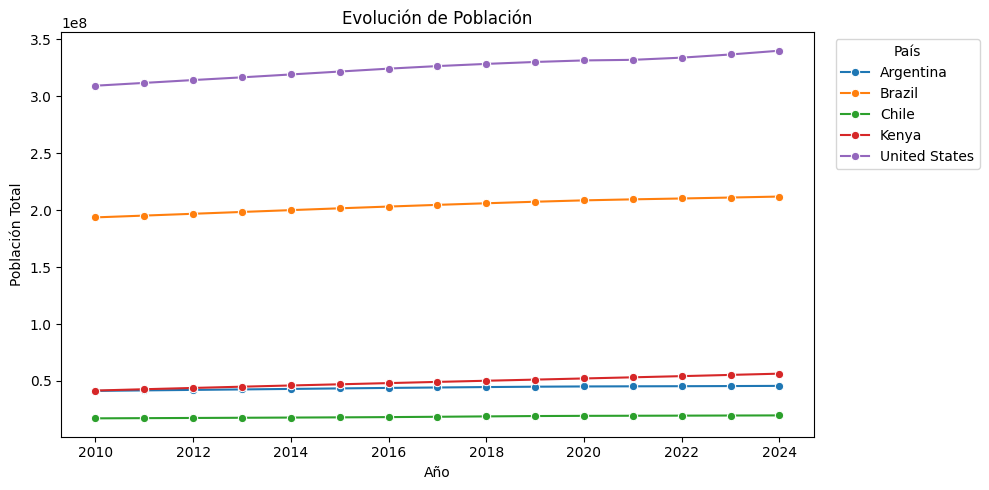

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(data=tablas['poblacion_total'],x='agno',y='valor',hue='pais',marker='o')
plt.title('Evolución de Población')
plt.xlabel('Año')
plt.ylabel('Población Total')
plt.legend(title='País',loc='upper left',bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

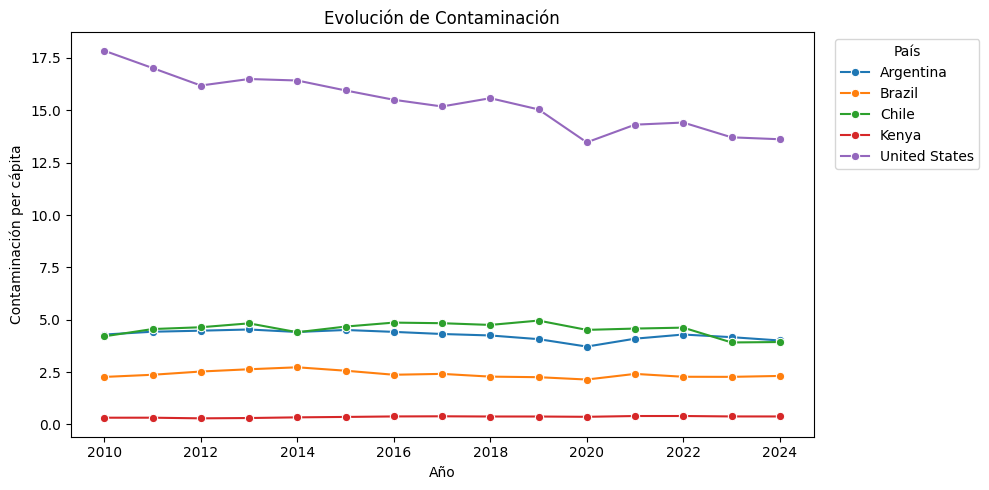

In [23]:
plt.figure(figsize=(10,5))
sns.lineplot(data=tablas['co2_per_capita'],x='agno',y='valor',hue='pais',marker='o')
plt.title('Evolución de Contaminación')
plt.xlabel('Año')
plt.ylabel('Contaminación per cápita')
plt.legend(title='País',loc='upper left',bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

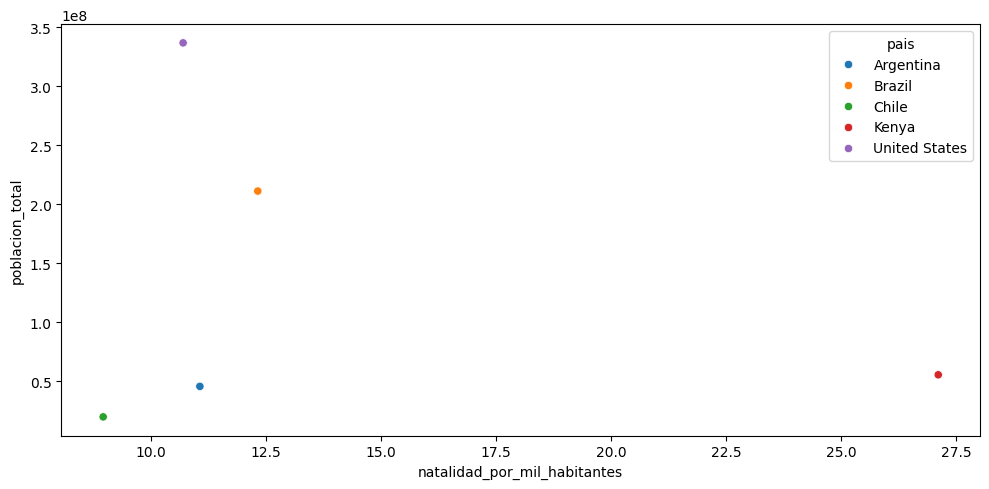

In [31]:
agno_reciente = 2023

natalidad_por_mil_habitantes = tablas['natalidad_por_mil_habitantes'].query('agno == @agno_reciente').rename(columns={'valor':'natalidad_por_mil_habitantes'})
poblacion_total = tablas['poblacion_total'].query('agno == @agno_reciente').rename(columns={'valor':'poblacion_total'})


df_mezclado = pd.merge(
    natalidad_por_mil_habitantes[['pais','natalidad_por_mil_habitantes']],
    poblacion_total[['pais','poblacion_total']],
    on = 'pais',
    how = 'inner'
)

plt.figure(figsize=(10,5))
sns.scatterplot(data=df_mezclado,x='natalidad_por_mil_habitantes',y='poblacion_total',hue='pais')
plt.tight_layout()
plt.show()